In [179]:
from database.adatabase import ADatabase
import pandas as pd
from modeler.modeler import Modeler as m
import matplotlib.pyplot as plt
from processor.processor import Processor as processor
from tqdm import tqdm
import warnings
warnings.simplefilter(action="ignore")
import pickle
from datetime import datetime, timedelta, timezone
from extractor.alp_extractor import ALPExtractor

In [180]:
db = ADatabase("algo")
market = ADatabase("market")
fed = ADatabase("fed")
market.connect()
sp500 = market.retrieve("sp500")
market.disconnect()
alp = ALPExtractor()

In [181]:
holding_period = 5
tickers = sp500["ticker"].values
positions = 10
hedge_percentage = 0.05
training_year = datetime.now().year - 3
today = datetime.now()
weekday = today.weekday() - 1 if today.weekday() != 0 else 4
week = today.isocalendar()[1] if today.weekday() != 0 else today.isocalendar()[1] - 1
week_mod = int(week % (holding_period/5))
print(week_mod,week)

0 50


In [193]:
market.connect()
prices = []
for ticker in tqdm(tickers,desc="model_prep"):
    try:
        ticker_prices = processor.column_date_processing(market.query("prices",{"ticker":ticker}))
        ticker_prices.sort_values("date",inplace=True)
        simulation = ticker_prices.copy()
        simulation.sort_values("date",inplace=True)
        simulation["historical_return"] = (simulation["adjclose"] - simulation["adjclose"].shift(100)) / simulation["adjclose"].shift(100)
        simulation["historical_volatility"] = simulation["adjclose"].rolling(100).std() / simulation["adjclose"].rolling(100).mean()
        simulation["historical_return_to_risk"] = simulation["historical_return"] / simulation["historical_volatility"]
        simulation["volatility"] = (simulation["adjclose"].rolling(holding_period).std() / simulation["adjclose"].rolling(holding_period).mean())
        simulation["current_return"] = (simulation["adjclose"] - simulation["adjclose"].shift(holding_period)) / simulation["adjclose"].shift(holding_period)
        simulation["return_to_risk"] = simulation["current_return"] / simulation["volatility"]
        simulation["expected_return"] = simulation["historical_return_to_risk"] * simulation["volatility"]
        simulation["buy_price"] = simulation["adjclose"]
        simulation["buy_date"] = simulation["date"].shift(-1)
        simulation["sell_price"] = simulation["adjclose"].shift(-holding_period)
        simulation["sell_date"] = simulation["date"] + timedelta(days=int(holding_period /5) * 7)
        simulation["return"] = (simulation["sell_price"] - simulation["buy_price"]) / simulation ["buy_price"] * (1/positions) *0.99
        simulation["return"] = [max(float(-hedge_percentage/positions),x) for x in simulation["return"]]
        prices.append(simulation)
    except Exception as e:
        print(str(e))
        continue
market.disconnect()

model_prep:  13%|████████████████▏                                                                                                            | 65/503 [00:10<00:48,  9.09it/s]

'date'


model_prep:  16%|████████████████████▏                                                                                                        | 81/503 [00:13<00:45,  9.19it/s]

'date'


model_prep: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 503/503 [01:16<00:00,  6.59it/s]

'date'


In [194]:
sim = pd.concat(prices).reset_index(drop=True)
sim.sort_values("date",inplace=True)
sim = processor.merge(sim,sp500,on="ticker")
fed.connect()
bench = fed.retrieve("sp500")
bench["date"] = pd.to_datetime(bench["date"],utc=True)
bench["value"] = [float(x) for x in bench["value"]]
fed.disconnect()
trades = sim[sim["weekday"]==weekday].copy()
trades = trades[trades["week"] % int(holding_period/5) == week_mod]
trades = processor.column_date_processing(trades)

In [195]:
## backtest
valuation_methods = ["historical_return"
                     ,"historical_volatility"
                     ,"historical_return_to_risk"
                     ,"volatility"
                     ,"current_return"
                     ,"return_to_risk"
                     ,"expected_return"]
reports = []
for valuation_method in tqdm(valuation_methods):
    try:
        iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
        portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
        portfolio.sort_values("date",inplace=True)
        portfolio["year"] = [x.year for x in portfolio["date"]]
        portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
        portfolio["return"] = portfolio["return"] + 1
        portfolio["cumulative_return"] = portfolio["return"].cumprod()
        portfolio = processor.column_date_processing(portfolio)
        portfolio = processor.merge(portfolio,bench.copy(),on="date")
        portfolio.dropna(inplace=True)
        portfolio["bench_cum_return"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
        portfolio["beta"] = portfolio["cumulative_return"].cov(portfolio["value"])
        portfolio["treynor"] = portfolio["cumulative_return"] / portfolio["beta"]
        portfolio["excess_return"] = portfolio["cumulative_return"] - portfolio["bench_cum_return"]
        portfolio["valuation_method"] = valuation_method
        reports.append(portfolio[["valuation_method","excess_return"]].tail(1))
    except Exception as e:
        print(str(e))
        continue

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:03<00:00,  2.07it/s]


In [196]:
report = pd.concat(reports)

In [197]:
report.sort_values("excess_return",ascending=False)

,valuation_method,excess_return
197,historical_volatility,55.782457
197,volatility,15.631469
197,historical_return,10.953845
197,current_return,6.523057
197,expected_return,5.367155
197,historical_return_to_risk,1.734476
197,return_to_risk,1.666210


In [198]:
valuation_method = "historical_volatility"

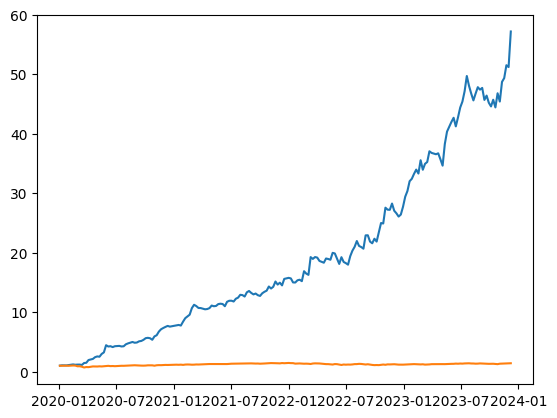

In [199]:
iteration_trades = trades.copy().sort_values(valuation_method,ascending=False).groupby(["date"]).nth([i for i in range(positions)]).reset_index()
iteration_trades = iteration_trades[["date","sell_date","ticker","adjclose","buy_price","sell_price",valuation_method,"return"]]
portfolio = iteration_trades[["date","return"]].groupby("date").sum().reset_index()
portfolio.sort_values("date",inplace=True)
portfolio["year"] = [x.year for x in portfolio["date"]]
portfolio = portfolio[(portfolio["date"]<portfolio["date"].max()) & (portfolio["year"]>=training_year)]
portfolio["return"] = portfolio["return"]  + 1
portfolio["cumulative_return"] = portfolio["return"].cumprod()
portfolio = processor.column_date_processing(portfolio)
portfolio = processor.merge(portfolio,bench.copy(),on="date")
portfolio.dropna(inplace=True)
portfolio["bench_cum_return"] = (portfolio["value"] - portfolio["value"].iloc[0]) / portfolio["value"].iloc[0] + 1
portfolio["excess_return"] = portfolio["cumulative_return"] - portfolio["bench_cum_return"]
recommendations = iteration_trades[["date","sell_date","ticker","adjclose",valuation_method]].sort_values(["date"]).tail(positions)
plt.plot(portfolio["date"].values,portfolio["cumulative_return"].values)
plt.plot(portfolio["date"].values,portfolio["bench_cum_return"].values)
plt.show()

In [200]:
portfolio.sort_values("date",ascending=False)

,date,return,year,cumulative_return,quarter,month,week,weekday,realtime_start,realtime_end,value,bench_cum_return,excess_return
197,2023-12-08 00:00:00+00:00,1.116775,2023,57.205822,4,12,49,4,2023-12-10,2023-12-10,4604.37,1.423364,55.782457
196,2023-12-01 00:00:00+00:00,0.994015,2023,51.224122,4,12,48,4,2023-12-10,2023-12-10,4594.63,1.420353,49.803769
195,2023-11-24 00:00:00+00:00,1.043877,2023,51.532532,4,11,47,4,2023-12-10,2023-12-10,4559.34,1.409444,50.123088
194,2023-11-17 00:00:00+00:00,1.013053,2023,49.366466,4,11,46,4,2023-12-10,2023-12-10,4514.02,1.395434,47.971032
193,2023-11-10 00:00:00+00:00,1.072866,2023,48.730406,4,11,45,4,2023-12-10,2023-12-10,4415.24,1.364898,47.365509
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,2020-01-31 00:00:00+00:00,1.051942,2020,1.118876,1,1,5,4,2023-12-10,2023-12-10,3225.52,0.997116,0.121760
3,2020-01-24 00:00:00+00:00,1.001296,2020,1.063629,1,1,4,4,2023-12-10,2023-12-10,3295.47,1.018740,0.044889
2,2020-01-17 00:00:00+00:00,0.988677,2020,1.062252,1,1,3,4,2023-12-10,2023-12-10,3329.62,1.029297,0.032956
1,2020-01-10 00:00:00+00:00,1.046497,2020,1.074417,1,1,2,4,2023-12-10,2023-12-10,3265.35,1.009429,0.064989


In [201]:
iteration_trades.sort_values("return",ascending=False).head(10)

,date,sell_date,ticker,adjclose,buy_price,sell_price,historical_volatility,return
720,2020-03-20 00:00:00+00:00,2020-03-27 00:00:00+00:00,CZR,8.820000,8.820000,15.140000,0.269914,0.070939
183,2020-04-03 00:00:00+00:00,2020-04-10 00:00:00+00:00,CZR,10.160000,10.160000,17.090000,0.375523,0.067527
201,2019-01-18 00:00:00+00:00,2019-01-25 00:00:00+00:00,PCG,7.230000,7.230000,12.010000,0.365072,0.065452
46,2020-05-29 00:00:00+00:00,2020-06-05 00:00:00+00:00,OXY,12.646406,12.646406,20.302608,0.532849,0.059935
210,2016-02-26 00:00:00+00:00,2016-03-04 00:00:00+00:00,ENPH,1.920000,1.920000,3.050000,0.360616,0.058266
145,2020-04-03 00:00:00+00:00,2020-04-10 00:00:00+00:00,APA,5.090688,5.090688,7.929361,0.402026,0.055204
51,2020-05-29 00:00:00+00:00,2020-06-05 00:00:00+00:00,UAL,28.040000,28.040000,42.405000,0.520753,0.050718
1190,2020-03-06 00:00:00+00:00,2020-03-13 00:00:00+00:00,EQT,6.184792,6.184792,9.223954,0.227795,0.048648
12,2020-05-29 00:00:00+00:00,2020-06-05 00:00:00+00:00,APA,10.239545,10.239545,15.250185,0.593359,0.048445
703,2022-03-11 00:00:00+00:00,2022-03-18 00:00:00+00:00,EPAM,200.140000,200.140000,294.470000,0.271138,0.046661


In [202]:
recommendations

,date,sell_date,ticker,adjclose,historical_volatility
1455,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,ILMN,127.10,0.211578
3123,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,MRNA,86.01,0.162810
1163,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,ALGN,255.01,0.229416
2098,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,ALB,147.06,0.187384
216,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,SEDG,97.12,0.358097
1408,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,PAYC,202.77,0.213680
2666,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,ENPH,123.92,0.173103
1706,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,PODD,206.97,0.201424
3244,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,DG,129.98,0.159855
1520,2023-12-15 00:00:00+00:00,2023-12-22 00:00:00+00:00,FMC,59.51,0.208258


In [203]:
db.connect()
db.drop('portfolio')
db.drop('trades')
db.drop('recommendations')
db.store("portfolio",portfolio)
db.store("trades",iteration_trades)
db.store("recommendations",recommendations)
db.disconnect()